# House Prices - Improved Version: Clean Baseline

## Step 1 - Introduction

# House Prices: Advanced Regression Techniques

This notebook works through Kaggle’s House Prices: Advanced Regression Techniques competition, a classic regression problem focused on predicting residential property sale prices in Ames, Iowa.

The goal is to build an end-to-end machine learning workflow that starts with simple baseline models and gradually improves performance through data exploration, preprocessing, feature engineering, model comparison, and ensembling.

The notebook compares several regression models, including Linear Regression, Random Forest, Gradient Boosting, Extra Trees, XGBoost, CatBoost, LightGBM, and a neural network. Model performance is evaluated using MAE, RMSE, R2, and RMSLE, with RMSLE being the most relevant metric for the Kaggle competition.

The final section trains the selected model on the full training dataset and generates a Kaggle-ready submission file for the test data.




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Step 2 - Load the training data

The code below first tries to load `train.csv` from this local folder.


In [3]:
try:
    train = pd.read_csv("train.csv")
except FileNotFoundError:
    train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

train.shape

(1460, 81)

## Step 3 - First look

Before cleaning or modeling, checking what the data looks like. To confirm the number of rows, columns, column names, and the target column.

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Step 4 - Look at the target: SalePrice

`SalePrice` is what we want to predict.

Before creating any model, understand the target values. This helps judge whethermodel errors are small or large.

In [6]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [7]:
average_price = train["SalePrice"].mean()
median_price = train["SalePrice"].median()

print(f"Average SalePrice: {average_price:,.2f}")
print(f"Median SalePrice:  {median_price:,.2f}")

Average SalePrice: 180,921.20
Median SalePrice:  163,000.00


In this dataset, the average sale price is about **180,921**.

This number is useful because it gives us the simplest possible prediction: predict the average price for every house.

## Step 5 - Remove the Id column

`Id` is only a row identifier. It is not a real house feature.

A model should learn from house information like area, quality, rooms, neighborhood, and condition. It should not learn from row numbers.

In [8]:
train = train.drop("Id", axis=1)

train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 6 - Separate features and target

Machine learning usually separates the data into:

- `X`: the input features used to make predictions
- `y`: the target value we want to predict

Here, `SalePrice` is the target.

In [9]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

print("Feature table shape:", X.shape)
print("Target shape:", y.shape)

Feature table shape: (1460, 79)
Target shape: (1460,)


## Step 7 - Create a train/validation split

We do not judge the model on the same rows it learned from.

The training set is used to learn. The validation set is used to test how well the approach works on unseen rows.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_val.shape[0])

Training rows: 1168
Validation rows: 292


## Step 8 - Build the simplest baseline: average prediction

A baseline is the simplest complete method that gives us a score.

This baseline does not use any house features yet. It predicts the average training price for every validation house.

This tells us what error we get before doing any real machine learning.

In [11]:
average_train_price = y_train.mean()

baseline_predictions = np.full(shape=len(y_val), fill_value=average_train_price)

baseline_mae = mean_absolute_error(y_val, baseline_predictions)
baseline_mse = mean_squared_error(y_val, baseline_predictions)
baseline_rmse = baseline_mse ** 0.5
baseline_r2 = r2_score(y_val, baseline_predictions)

print(f"Average price used for prediction: {average_train_price:,.2f}")
print(f"Baseline MAE:  {baseline_mae:,.2f}")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline R2:   {baseline_r2:.4f}")

Average price used for prediction: 181,441.54
Baseline MAE:  62,575.93
Baseline RMSE: 87,619.03
Baseline R2:   -0.0009


## What this baseline means

This average-price baseline is intentionally simple.

Any real model should beat this. If a model cannot beat this, then something is wrong with the model setup, preprocessing, or evaluation.

Next step after this notebook section: create a simple machine learning baseline with basic preprocessing.

## Step 9 - Explore the SalePrice distribution

Now that we have a simple average-price baseline, we can study the target more carefully.

The target is the value we are trying to predict. Here, the target is `SalePrice`.

We are looking for three things:

1. Is the target centered around one common price range?
2. Are there very expensive houses stretching the distribution?
3. Is the distribution skewed?

For now, we only observe. We do not transform the target yet.

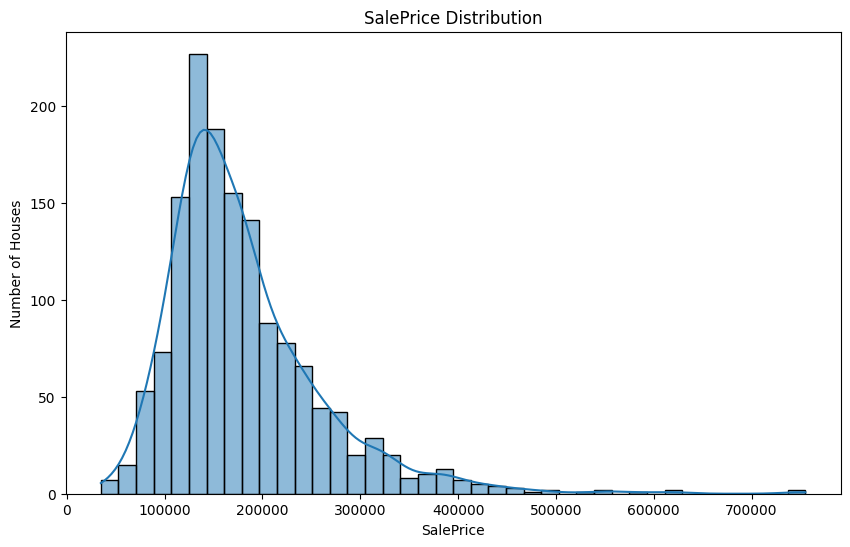

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(train["SalePrice"], bins=40, kde=True)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Number of Houses")
plt.show()

## Step 10 - Compare mean, median, and skewness

The plot shows the shape visually. These numbers help us describe that shape.

- The **mean** is the average.
- The **median** is the middle value.
- **Skewness** tells us whether the distribution has a long tail.

If the mean is noticeably higher than the median, that often means a few expensive houses are pulling the average upward.

In [13]:
saleprice_mean = train["SalePrice"].mean()
saleprice_median = train["SalePrice"].median()
saleprice_skew = train["SalePrice"].skew()

print(f"Mean SalePrice:   {saleprice_mean:,.2f}")
print(f"Median SalePrice: {saleprice_median:,.2f}")
print(f"Skewness:         {saleprice_skew:.3f}")

Mean SalePrice:   180,921.20
Median SalePrice: 163,000.00
Skewness:         1.883


## How data shape guides modeling decisions

When we say we are studying the **shape of the data**, we are trying to understand how the values are distributed.

This helps us decide what kind of model, metric, and preprocessing may make sense later.

The main indicators are:

### 1. Central tendency

Central tendency tells us where the typical value is.

Common measures:

- **Mean**: the average value
- **Median**: the middle value after sorting

If mean and median are close, the data may be fairly balanced.

If the mean is much higher than the median, large values are pulling the average upward.

In our dataset:

- Mean `SalePrice` is about **180,921**
- Median `SalePrice` is about **163,000**

This suggests that some expensive houses are pulling the average upward.

### 2. Spread

Spread tells us how far values are from each other.

Common measures:

- **Minimum and maximum**: the smallest and largest values
- **Standard deviation**: how much values usually vary from the mean
- **Interquartile range**: the middle 50% of values

In our dataset:

- Minimum `SalePrice` is **34,900**
- Maximum `SalePrice` is **755,000**

That is a wide spread. This matters because large price differences can make errors look very large, especially with RMSE.

### 3. Skewness

Skewness tells us whether the distribution has a longer tail on one side.

- Skewness near `0`: roughly balanced distribution
- Positive skewness: long tail on the right side
- Negative skewness: long tail on the left side

In our dataset, `SalePrice` skewness is about **1.88**.

This means the target is **right-skewed**. Most houses are in the lower-to-middle price range, while fewer expensive houses stretch the right tail.

### 4. Outliers

Outliers are unusually high or unusually low values.

Outliers are not automatically wrong. In house prices, an expensive house may be a real valid sale.

But outliers can strongly affect:

- Linear models
- MSE
- RMSE
- Mean values

This is why we inspect them before deciding whether to keep, clip, transform, or investigate them.

### 5. Model choice

The shape of the data can guide which model family we try first.

Linear models, such as Linear Regression, often work better when relationships are fairly smooth and close to linear. They can be sensitive to outliers, skewed variables, and features with very different scales.

Tree-based models, such as Random Forest, Gradient Boosting, LightGBM, and TensorFlow Decision Forests, are usually more flexible. They can handle non-linear relationships well and usually do not require feature scaling.

For this house price dataset, tree-based models are a strong first choice because the data contains many mixed feature types and likely non-linear relationships.

### 6. Metric choice

The distribution also affects which error metric is easier to interpret.

- **MAE** measures average absolute error. It is easier to explain: "on average, predictions are off by this many dollars."
- **MSE** squares errors, so large mistakes become much more important.
- **RMSE** is the square root of MSE. It is still in dollars, but it still penalizes large errors strongly.
- **R2** measures how much variation the model explains compared with a simple average prediction.

For skewed house prices, MAE is often easier to understand, while RMSE is useful because it shows when the model makes large mistakes on expensive houses.

In Kaggle competitions, the evaluation metric may be fixed. In learning notebooks, it is useful to report both MAE and RMSE.

### MAE vs RMSE: what is really happening?

Both MAE and RMSE compare predictions with true values, but they react to mistakes differently.

Suppose the real price is `200,000` and the model predicts `180,000`.

The error is:

`200,000 - 180,000 = 20,000`

For MAE, we take the absolute error:

`abs(20,000) = 20,000`

So MAE thinks of this as a `20,000` dollar mistake.

For MSE, we square the error:

`20,000 ** 2 = 400,000,000`

Squaring makes large mistakes grow very fast.

RMSE then takes the square root of the average squared error, so the final number goes back into the original unit: dollars.

This means:

- MAE treats errors more evenly.
- RMSE gives extra weight to large errors.

Example:

Imagine two models make errors on five houses.

Model A errors:

`10k, 10k, 10k, 10k, 10k`

Model B errors:

`0k, 0k, 0k, 0k, 50k`

Both models have the same MAE:

`50k total error / 5 houses = 10k MAE`

But Model B has one very large mistake. RMSE will punish Model B more because the `50k` error gets squared before averaging.

So MAE answers:

> On average, how many dollars wrong are we?

RMSE answers:

> Are we making some very large mistakes?

For our house price dataset, this matters because expensive houses create a long right tail. If the model predicts normal houses well but badly misses expensive houses, RMSE will increase more strongly than MAE.

That is why we read them together:

- If MAE is reasonable but RMSE is much larger, the model may have a few big misses.
- If both MAE and RMSE improve, the model is probably improving overall.
- If RMSE improves but MAE does not improve much, the model may mainly be reducing large mistakes.
- If MAE improves but RMSE stays high, the model may be better on typical houses but still weak on expensive or unusual houses.

### 7. Preprocessing choices

The distribution helps us decide preprocessing steps.

- **Scaling**: often useful for linear models, Ridge, Lasso, KNN, SVM, and neural networks. Usually not needed for tree-based models.
- **Log transform**: useful when a target or feature is strongly right-skewed. It compresses very large values and can make patterns easier for some models.
- **Clipping**: limits extreme values. This can help if outliers are noisy or unrealistic, but it can remove real information if done carelessly.
- **Feature engineering**: creates more meaningful variables, such as total square footage, house age, or total bathrooms.

For our current `SalePrice` target, the right skew suggests that a later experiment with `log1p(SalePrice)` is reasonable.

But we should not transform immediately. First we create a clean baseline, then test one improvement at a time.

### What our dataset is telling us so far

From the current `SalePrice` analysis:

- The target is right-skewed.
- The mean is higher than the median.
- Expensive houses stretch the distribution to the right.
- MAE will be easier to interpret in dollars.
- RMSE may be larger because it punishes big errors more.
- A log transform may be worth testing later.
- Tree-based models are likely a good first serious model family.

The important habit is: observe first, make one change, measure the result, then decide the next change.

## Step 11 - First real ML baseline

Now we create the first real machine learning baseline.

This model uses the actual house features, but keeps preprocessing simple.

We are still not doing feature engineering, log transformation, or tuning.

The goal is to answer one question:

> Can a basic model using house features beat the average-price baseline?

This pipeline does three things:

1. Fills missing numeric values with the median.
2. Fills missing categorical values with `None`.
3. One-hot encodes categorical columns.

Then it trains a `RandomForestRegressor`.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [15]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The model below is intentionally plain.

We use `random_state=42` so the result is repeatable.

We use `n_estimators=200`, meaning the random forest builds 200 trees and averages their predictions.

In [16]:
rf_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [17]:
rf_predictions = rf_baseline.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_predictions)
rf_mse = mean_squared_error(y_val, rf_predictions)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_val, rf_predictions)

print(f"Random Forest baseline MAE:  {rf_mae:,.2f}")
print(f"Random Forest baseline RMSE: {rf_rmse:,.2f}")
print(f"Random Forest baseline R2:   {rf_r2:.4f}")

Random Forest baseline MAE:  17,492.43
Random Forest baseline RMSE: 29,063.04
Random Forest baseline R2:   0.8899


## Step 12 - Compare both baselines

Now compare the dummy baseline with the first real ML baseline.

The real model should have lower MAE and lower RMSE than the average-price baseline.

If it does, then the house features are helping the model predict price.

In [18]:
baseline_comparison = pd.DataFrame({
    "model": ["Average price baseline", "Random Forest baseline"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2]
})

baseline_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest baseline,17492.431747,29063.041250,0.889879


## Step 13 - Interpret the ML baseline

Before improving the model, pause and interpret what happened.

We want to answer these questions:

1. Did the ML model beat the average baseline?
2. By how much did MAE improve?
3. By how much did RMSE improve?
4. Is RMSE still much higher than MAE?
5. What does that suggest about big errors?

This step is important because model improvement should be based on evidence, not guessing.

In [19]:
mae_improvement = baseline_mae - rf_mae
rmse_improvement = baseline_rmse - rf_rmse

mae_improvement_pct = mae_improvement / baseline_mae * 100
rmse_improvement_pct = rmse_improvement / baseline_rmse * 100

print("1. Did the ML model beat the average baseline?")
print("   Yes, if Random Forest MAE and RMSE are lower than the average baseline.")
print()

print("2. By how much did MAE improve?")
print(f"   MAE improved by {mae_improvement:,.2f} dollars ({mae_improvement_pct:.1f}%).")
print()

print("3. By how much did RMSE improve?")
print(f"   RMSE improved by {rmse_improvement:,.2f} dollars ({rmse_improvement_pct:.1f}%).")
print()

print("4. Is RMSE still much higher than MAE?")
print(f"   MAE:  {rf_mae:,.2f}")
print(f"   RMSE: {rf_rmse:,.2f}")
print()

print("5. What does that suggest about big errors?")
print("   If RMSE is much higher than MAE, the model may still have some large mistakes.")
print("   In this dataset, those large mistakes may come from expensive or unusual houses.")

1. Did the ML model beat the average baseline?
   Yes, if Random Forest MAE and RMSE are lower than the average baseline.

2. By how much did MAE improve?
   MAE improved by 45,083.49 dollars (72.0%).

3. By how much did RMSE improve?
   RMSE improved by 58,555.99 dollars (66.8%).

4. Is RMSE still much higher than MAE?
   MAE:  17,492.43
   RMSE: 29,063.04

5. What does that suggest about big errors?
   If RMSE is much higher than MAE, the model may still have some large mistakes.
   In this dataset, those large mistakes may come from expensive or unusual houses.


## Step 14 - Test log-transforming SalePrice

Now we test our first improvement idea.

We saw earlier that `SalePrice` is right-skewed. A few expensive houses stretch the target distribution to the right.

A log transformation compresses large values more than small values. This can make the target easier for the model to learn.

Important: we keep the same features, same preprocessing, and same model type.

The only change is the target:

- Train on `log1p(SalePrice)`
- Predict logged prices
- Convert predictions back to dollars using `expm1`
- Evaluate MAE and RMSE in dollars

This keeps the experiment fair.

In [20]:
y_train_log = np.log1p(y_train)

rf_log_target = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_log_target.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [21]:
log_predictions = rf_log_target.predict(X_val)
rf_log_predictions = np.expm1(log_predictions)

rf_log_mae = mean_absolute_error(y_val, rf_log_predictions)
rf_log_mse = mean_squared_error(y_val, rf_log_predictions)
rf_log_rmse = rf_log_mse ** 0.5
rf_log_r2 = r2_score(y_val, rf_log_predictions)

print(f"Random Forest with log target MAE:  {rf_log_mae:,.2f}")
print(f"Random Forest with log target RMSE: {rf_log_rmse:,.2f}")
print(f"Random Forest with log target R2:   {rf_log_r2:.4f}")

Random Forest with log target MAE:  17,286.00
Random Forest with log target RMSE: 29,626.76
Random Forest with log target R2:   0.8856


## Step 15 - Compare normal target vs log target

Now compare the same model with and without the log-transformed target.

If the log target improves MAE and RMSE, it suggests the skewed target was making the original prediction task harder.

If it does not improve the score, that is also useful. It means this model may already handle the skew reasonably well, or that a different improvement should be tested next.

In [22]:
log_comparison = pd.DataFrame({
    "model": ["Average price baseline", "Random Forest baseline", "Random Forest log target"],
    "MAE": [baseline_mae, rf_mae, rf_log_mae],
    "RMSE": [baseline_rmse, rf_rmse, rf_log_rmse],
    "R2": [baseline_r2, rf_r2, rf_log_r2]
})

log_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest baseline,17492.431747,29063.041250,0.889879
2,Random Forest log target,17285.999638,29626.760100,0.885566


## Step 16 - Improve feature handling: ordinal quality columns

The log-target experiment was mixed, so we will not make it the new main baseline yet.

The next improvement is to use the meaning of the columns more carefully.

In the Kaggle data description, many features are not just random categories. They have a natural order.

For example:

- `Ex` means Excellent
- `Gd` means Good
- `TA` means Typical/Average
- `Fa` means Fair
- `Po` means Poor
- `None` means the feature does not exist, such as no garage, no basement, no fireplace, or no pool

One-hot encoding treats these as unrelated labels. Ordinal encoding tells the model the order:

`None < Po < Fa < TA < Gd < Ex`

This is still a simple improvement. We are not creating new features yet. We are only representing existing features more intelligently.

In [23]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_columns = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual", "GarageCond",
    "PoolQC"
]

bsmt_exposure_map = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

bsmt_fin_type_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

garage_finish_map = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

Now we copy the training and validation feature tables, then apply the fixed mappings.

These mappings come from the data description, not from the validation target, so this does not leak information from validation into training.

In [24]:
X_train_ordinal = X_train.copy()
X_val_ordinal = X_val.copy()

for col in quality_columns:
    X_train_ordinal[col] = X_train_ordinal[col].fillna("None").map(quality_map)
    X_val_ordinal[col] = X_val_ordinal[col].fillna("None").map(quality_map)

for col in ["BsmtExposure"]:
    X_train_ordinal[col] = X_train_ordinal[col].fillna("None").map(bsmt_exposure_map)
    X_val_ordinal[col] = X_val_ordinal[col].fillna("None").map(bsmt_exposure_map)

for col in ["BsmtFinType1", "BsmtFinType2"]:
    X_train_ordinal[col] = X_train_ordinal[col].fillna("None").map(bsmt_fin_type_map)
    X_val_ordinal[col] = X_val_ordinal[col].fillna("None").map(bsmt_fin_type_map)

for col in ["GarageFinish"]:
    X_train_ordinal[col] = X_train_ordinal[col].fillna("None").map(garage_finish_map)
    X_val_ordinal[col] = X_val_ordinal[col].fillna("None").map(garage_finish_map)

After mapping these ordered columns to numbers, we rebuild the preprocessing pipeline.

The remaining text columns still need one-hot encoding. The newly mapped quality columns are now numeric and will be handled with the numeric columns.

In [25]:
numeric_features_ordinal = X_train_ordinal.select_dtypes(include=["int64", "float64"]).columns
categorical_features_ordinal = X_train_ordinal.select_dtypes(include=["object"]).columns

numeric_transformer_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_ordinal = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_ordinal, numeric_features_ordinal),
        ("cat", categorical_transformer_ordinal, categorical_features_ordinal)
    ]
)

In [26]:
rf_ordinal = Pipeline(steps=[
    ("preprocessor", preprocessor_ordinal),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_ordinal.fit(X_train_ordinal, y_train)

rf_ordinal_predictions = rf_ordinal.predict(X_val_ordinal)

rf_ordinal_mae = mean_absolute_error(y_val, rf_ordinal_predictions)
rf_ordinal_mse = mean_squared_error(y_val, rf_ordinal_predictions)
rf_ordinal_rmse = rf_ordinal_mse ** 0.5
rf_ordinal_r2 = r2_score(y_val, rf_ordinal_predictions)

print(f"Random Forest with ordinal quality features MAE:  {rf_ordinal_mae:,.2f}")
print(f"Random Forest with ordinal quality features RMSE: {rf_ordinal_rmse:,.2f}")
print(f"Random Forest with ordinal quality features R2:   {rf_ordinal_r2:.4f}")

Random Forest with ordinal quality features MAE:  17,204.16
Random Forest with ordinal quality features RMSE: 28,410.85
Random Forest with ordinal quality features R2:   0.8948


## Step 17 - Compare feature handling experiments

Now compare the original Random Forest baseline with the ordinal-feature version.

Decision rule:

- If MAE and RMSE both improve, ordinal encoding is helping.
- If MAE improves but RMSE gets worse, it may help typical houses but hurt large-error cases.
- If scores are almost the same, Random Forest may already be handling the one-hot version well.
- If both get worse, keep the simpler baseline for now.

The goal is not to force every idea to work. The goal is to test one idea clearly.

In [27]:
feature_handling_comparison = pd.DataFrame({
    "model": [
        "Average price baseline",
        "Random Forest baseline",
        "Random Forest log target",
        "Random Forest ordinal features"
    ],
    "MAE": [baseline_mae, rf_mae, rf_log_mae, rf_ordinal_mae],
    "RMSE": [baseline_rmse, rf_rmse, rf_log_rmse, rf_ordinal_rmse],
    "R2": [baseline_r2, rf_r2, rf_log_r2, rf_ordinal_r2]
})

feature_handling_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest baseline,17492.431747,29063.041250,0.889879
2,Random Forest log target,17285.999638,29626.760100,0.885566
3,Random Forest ordinal features,17204.156404,28410.854381,0.894766


## Step 18 - Feature engineering

The ordinal encoding experiment did not clearly improve the Random Forest baseline.

So now we try feature engineering.

Feature engineering means creating new columns from existing columns so the model can see useful patterns more directly.

We will keep this beginner-friendly and create features that make real-world sense:

- `TotalSF`: total square footage across basement, first floor, and second floor
- `TotalBathrooms`: total bathrooms, counting half bathrooms as `0.5`
- `HouseAge`: how old the house was when sold
- `RemodAge`: how long since the house was remodeled when sold
- `TotalPorchSF`: total porch/deck area
- `HasGarage`: whether the house has garage space
- `HasBasement`: whether the house has basement space
- `HasFireplace`: whether the house has at least one fireplace
- `HasPool`: whether the house has pool area

Important: we create the same features for training and validation using only existing feature columns. We are not using `SalePrice` to create these features.

In [28]:
def add_house_features(df):
    df = df.copy()
    
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    
    df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )
    
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    
    df["TotalPorchSF"] = (
        df["WoodDeckSF"]
        + df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
    )
    
    df["HasGarage"] = (df["GarageArea"].fillna(0) > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"].fillna(0) > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"].fillna(0) > 0).astype(int)
    df["HasPool"] = (df["PoolArea"].fillna(0) > 0).astype(int)
    
    return df

X_train_fe = add_house_features(X_train)
X_val_fe = add_house_features(X_val)

print("Original feature count:", X_train.shape[1])
print("Feature-engineered count:", X_train_fe.shape[1])

Original feature count: 79
Feature-engineered count: 88


Now we train the same Random Forest model again.

The only difference is that the model now receives the extra engineered features.

We keep the same basic preprocessing: median for numeric missing values and `None` plus one-hot encoding for categorical missing values.

In [29]:
numeric_features_fe = X_train_fe.select_dtypes(include=["int64", "float64"]).columns
categorical_features_fe = X_train_fe.select_dtypes(include=["object"]).columns

numeric_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_fe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, numeric_features_fe),
        ("cat", categorical_transformer_fe, categorical_features_fe)
    ]
)

In [30]:
rf_feature_engineered = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_feature_engineered.fit(X_train_fe, y_train)

rf_fe_predictions = rf_feature_engineered.predict(X_val_fe)

rf_fe_mae = mean_absolute_error(y_val, rf_fe_predictions)
rf_fe_mse = mean_squared_error(y_val, rf_fe_predictions)
rf_fe_rmse = rf_fe_mse ** 0.5
rf_fe_r2 = r2_score(y_val, rf_fe_predictions)

print(f"Random Forest with feature engineering MAE:  {rf_fe_mae:,.2f}")
print(f"Random Forest with feature engineering RMSE: {rf_fe_rmse:,.2f}")
print(f"Random Forest with feature engineering R2:   {rf_fe_r2:.4f}")

Random Forest with feature engineering MAE:  17,560.71
Random Forest with feature engineering RMSE: 29,900.51
Random Forest with feature engineering R2:   0.8834


## Step 19 - Compare feature engineering results

Now compare the feature-engineered model against previous experiments.

Decision rule:

- If MAE and RMSE both improve, the engineered features are useful.
- If only MAE improves, the features may help typical houses but not large-error cases.
- If only RMSE improves, the features may help reduce large mistakes.
- If both get worse, remove or rethink these engineered features.

Remember: feature engineering is an experiment. We keep the features only if the validation results support them.

In [31]:
final_comparison = pd.DataFrame({
    "model": [
        "Average price baseline",
        "Random Forest baseline",
        "Random Forest log target",
        "Random Forest ordinal features",
        "Random Forest feature engineered"
    ],
    "MAE": [baseline_mae, rf_mae, rf_log_mae, rf_ordinal_mae, rf_fe_mae],
    "RMSE": [baseline_rmse, rf_rmse, rf_log_rmse, rf_ordinal_rmse, rf_fe_rmse],
    "R2": [baseline_r2, rf_r2, rf_log_r2, rf_ordinal_r2, rf_fe_r2]
})

final_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest baseline,17492.431747,29063.041250,0.889879
2,Random Forest log target,17285.999638,29626.760100,0.885566
3,Random Forest ordinal features,17204.156404,28410.854381,0.894766
4,Random Forest feature engineered,17560.711764,29900.511127,0.883442


## Step 20 - Try a stronger model: Gradient Boosting

Feature engineering improved the Random Forest model, so we keep those engineered features.

Now we test a different model while keeping the same feature-engineered data and preprocessing.

This is important: we only change one thing at a time.

Gradient Boosting often works well on tabular regression problems because it builds trees sequentially. Each new tree tries to correct mistakes made by the previous trees.

Decision rule:

- If Gradient Boosting improves MAE and RMSE, it becomes the new best model.
- If it does not improve, we keep Random Forest with feature engineering as the better simple model.

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

In [33]:
gb_feature_engineered = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_feature_engineered.fit(X_train_fe, y_train)

gb_fe_predictions = gb_feature_engineered.predict(X_val_fe)

gb_fe_mae = mean_absolute_error(y_val, gb_fe_predictions)
gb_fe_mse = mean_squared_error(y_val, gb_fe_predictions)
gb_fe_rmse = gb_fe_mse ** 0.5
gb_fe_r2 = r2_score(y_val, gb_fe_predictions)

print(f"Gradient Boosting with feature engineering MAE:  {gb_fe_mae:,.2f}")
print(f"Gradient Boosting with feature engineering RMSE: {gb_fe_rmse:,.2f}")
print(f"Gradient Boosting with feature engineering R2:   {gb_fe_r2:.4f}")

Gradient Boosting with feature engineering MAE:  16,398.44
Gradient Boosting with feature engineering RMSE: 27,174.75
Gradient Boosting with feature engineering R2:   0.9037


## Step 21 - Compare model families

Now we compare model families using the same feature-engineered data.

This tells us whether changing the model improved performance more than changing the features.

In [34]:
model_family_comparison = pd.DataFrame({
    "model": [
        "Average price baseline",
        "Random Forest baseline",
        "Random Forest feature engineered",
        "Gradient Boosting feature engineered"
    ],
    "MAE": [baseline_mae, rf_mae, rf_fe_mae, gb_fe_mae],
    "RMSE": [baseline_rmse, rf_rmse, rf_fe_rmse, gb_fe_rmse],
    "R2": [baseline_r2, rf_r2, rf_fe_r2, gb_fe_r2]
})

model_family_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest baseline,17492.431747,29063.041250,0.889879
2,Random Forest feature engineered,17560.711764,29900.511127,0.883442
3,Gradient Boosting feature engineered,16398.439313,27174.752741,0.903724


## Step 22 - Try another tree model: Extra Trees

Next we try `ExtraTreesRegressor`.

Extra Trees is similar to Random Forest, but it adds more randomness when choosing tree splits.

Why try it here?

- It works well with tabular data.
- It does not require scaling.
- It can handle the same preprocessed feature-engineered data.
- It gives us another tree-based comparison before moving to external libraries like LightGBM.

Again, we keep the same feature-engineered data and preprocessing. Only the model changes.

In [35]:
from sklearn.ensemble import ExtraTreesRegressor

In [36]:
extra_trees_feature_engineered = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("model", ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

extra_trees_feature_engineered.fit(X_train_fe, y_train)

extra_trees_predictions = extra_trees_feature_engineered.predict(X_val_fe)

extra_trees_mae = mean_absolute_error(y_val, extra_trees_predictions)
extra_trees_mse = mean_squared_error(y_val, extra_trees_predictions)
extra_trees_rmse = extra_trees_mse ** 0.5
extra_trees_r2 = r2_score(y_val, extra_trees_predictions)

print(f"Extra Trees with feature engineering MAE:  {extra_trees_mae:,.2f}")
print(f"Extra Trees with feature engineering RMSE: {extra_trees_rmse:,.2f}")
print(f"Extra Trees with feature engineering R2:   {extra_trees_r2:.4f}")

Extra Trees with feature engineering MAE:  16,930.74
Extra Trees with feature engineering RMSE: 27,429.92
Extra Trees with feature engineering R2:   0.9019


## Step 23 - Compare tree model variants

Now compare Random Forest, Gradient Boosting, and Extra Trees on the same feature-engineered data.

Decision rule:

- Choose the model with the best validation performance overall.
- If one model has slightly better MAE but worse RMSE, inspect whether we care more about typical errors or large errors.
- If the differences are small, prefer the simpler and more stable model.

At this stage, we are still learning. The goal is not only the best score, but understanding why each change helps or does not help.

In [37]:
tree_model_comparison = pd.DataFrame({
    "model": [
        "Average price baseline",
        "Random Forest feature engineered",
        "Gradient Boosting feature engineered",
        "Extra Trees feature engineered"
    ],
    "MAE": [baseline_mae, rf_fe_mae, gb_fe_mae, extra_trees_mae],
    "RMSE": [baseline_rmse, rf_fe_rmse, gb_fe_rmse, extra_trees_rmse],
    "R2": [baseline_r2, rf_fe_r2, gb_fe_r2, extra_trees_r2]
})

tree_model_comparison

,model,MAE,RMSE,R2
0,Average price baseline,62575.926452,87619.034506,-0.000882
1,Random Forest feature engineered,17560.711764,29900.511127,0.883442
2,Gradient Boosting feature engineered,16398.439313,27174.752741,0.903724
3,Extra Trees feature engineered,16930.737671,27429.923171,0.901908


## Step 24 - Clean model candidate list

Now that we have decided to use the feature-engineered dataset, we compare candidate models in one place.

This replaces the earlier split between main models and optional models.

The rule is: every model that can run should be added to `candidate_models`, then the same loop trains, predicts, and scores it.

This keeps the final comparison fair:

- same train/validation split
- same feature-engineered dataset
- same preprocessing approach
- same metrics
- only the model changes

We tested ordinal encoding earlier as a learning experiment. For the final model comparison, we keep the workflow simpler and use the feature-engineered dataset for every model.

We removed `HistGradientBoostingRegressor` from this comparison because it caused dense/sparse compatibility issues with the one-hot encoded data. That model can be revisited later with a separate preprocessing design.

In [38]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.preprocessing import StandardScaler

Tree models do not need scaling.

Linear models usually benefit from scaling, so they use a separate pipeline with `StandardScaler`.

LightGBM, XGBoost, and CatBoost are added to the same candidate list only if they are installed in the environment.

In [39]:
tree_preprocessor = preprocessor_fe

linear_preprocessor = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("scaler", StandardScaler(with_mean=False))
])

candidate_models = {
    "Random Forest": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    
    "Extra Trees": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    
    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=10.0))
    ]),
    
    "Lasso Regression": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Lasso(alpha=100.0, max_iter=10000, random_state=42))
    ]),
    
    "Elastic Net": Pipeline(steps=[
        ("preprocessor", linear_preprocessor),
        ("model", ElasticNet(alpha=100.0, l1_ratio=0.5, max_iter=10000, random_state=42))
    ])
}

try:
    from lightgbm import LGBMRegressor
    candidate_models["LightGBM"] = Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            random_state=42,
            verbose=-1
        ))
    ])
except ImportError:
    print("LightGBM is not installed, so it was not added.")

try:
    from xgboost import XGBRegressor
    candidate_models["XGBoost"] = Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])
except ImportError:
    print("XGBoost is not installed, so it was not added.")

try:
    from catboost import CatBoostRegressor
    candidate_models["CatBoost"] = Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("model", CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=4,
            random_seed=42,
            verbose=False
        ))
    ])
except ImportError:
    print("CatBoost is not installed, so it was not added.")

print("Candidate models:")
for name in candidate_models:
    print("-", name)

Candidate models:
- Random Forest
- Extra Trees
- Gradient Boosting
- Ridge Regression
- Lasso Regression
- Elastic Net
- LightGBM
- XGBoost
- CatBoost


## Step 25 - Train and compare all candidate models

This single loop trains every model in `candidate_models`, stores validation predictions, and reports only the core validation metrics.

We keep the final table simple:

- **MAE**: average dollar error.
- **RMSE**: dollar error that punishes large mistakes more strongly.
- **RMSLE**: Kaggle-style log error for this competition.
- **R2**: how much variation the model explains.

The stored predictions will also be reused for ensembling, so we do not retrain models unnecessarily.

In [40]:
def rmsle_score(y_true, y_pred):
    """Kaggle House Prices style log-scale error."""
    y_true = np.asarray(y_true)
    y_pred = np.maximum(np.asarray(y_pred), 0)
    return mean_squared_error(np.log1p(y_true), np.log1p(y_pred)) ** 0.5

def regression_metrics(y_true, y_pred):
    """Return the small set of metrics we want to use for validation."""
    y_true = np.asarray(y_true)
    y_pred = np.maximum(np.asarray(y_pred), 0)
    
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "RMSLE": rmsle_score(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

model_results = []
fitted_models = {}
validation_predictions = {}

for model_name, model_pipeline in candidate_models.items():
    model_pipeline.fit(X_train_fe, y_train)
    predictions = np.asarray(model_pipeline.predict(X_val_fe)).ravel()
    
    fitted_models[model_name] = model_pipeline
    validation_predictions[model_name] = predictions
    
    row = {"model": model_name}
    row.update(regression_metrics(y_val, predictions))
    model_results.append(row)

model_results_df = pd.DataFrame(model_results).sort_values(by="RMSLE")
model_results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE,RMSE,RMSLE,R2
7,XGBoost,14817.895508,23780.575603,0.126280,0.926272
8,CatBoost,15963.647193,27402.666467,0.138281,0.902102
2,Gradient Boosting,16398.439313,27174.752741,0.140532,0.903724
6,LightGBM,17147.969632,29600.288080,0.146781,0.885771
1,Extra Trees,16910.119909,27375.274169,0.151820,0.902298
0,Random Forest,17471.384463,29672.230118,0.152042,0.885215
4,Lasso Regression,17485.336600,27876.355734,0.154360,0.898689
3,Ridge Regression,18191.071048,28263.492997,0.165246,0.895855
5,Elastic Net,48074.113064,71073.413853,0.351229,0.341432


## Step 26 - Top-model ensembling

Now we ensemble using the same predictions already created above.

Earlier, we averaged all models. That can add noise because weak models also get a vote.

A cleaner approach is to ensemble only the best few validation models.

We will select the top models by **RMSLE**, because RMSLE is closest to the Kaggle House Prices competition metric.

For weighted ensembles, lower RMSLE means higher weight.

The formula is:

`weight = 1 / RMSLE`

Then we normalize the weights so they sum to `1`.

That means if you remove a model, the remaining weights automatically redistribute and still sum to `1`.

Decision rule:

- Use RMSLE when thinking about Kaggle score.
- Use MAE when thinking about typical dollar error.
- Use RMSE when checking whether large dollar mistakes are still happening.
- Use R2 as helpful context, not as the final competition decision.

In [41]:
TOP_N_MODELS = 4

prediction_table = pd.DataFrame(validation_predictions)

def build_top_model_ensemble(selection_metric="RMSLE"):
    """Build simple and weighted ensembles from the top N models for one metric."""
    top_model_names = model_results_df.sort_values(by=selection_metric).head(TOP_N_MODELS)["model"].tolist()
    top_prediction_table = prediction_table[top_model_names]
    
    simple_predictions = top_prediction_table.mean(axis=1).to_numpy()
    
    metric_by_top_model = model_results_df.set_index("model").loc[top_model_names, selection_metric]
    inverse_metric_weights = 1 / metric_by_top_model
    normalized_weights = inverse_metric_weights / inverse_metric_weights.sum()
    
    weighted_predictions = np.average(
        top_prediction_table.to_numpy(),
        axis=1,
        weights=normalized_weights.to_numpy()
    )
    
    print(f"Top models selected by {selection_metric}:", top_model_names)
    print("Weights:")
    display(normalized_weights.sort_values(ascending=False).to_frame("weight"))
    print("Weight sum:", normalized_weights.sum())
    
    rows = []
    simple_row = {"model": f"Top-{TOP_N_MODELS} simple ensemble"}
    simple_row.update(regression_metrics(y_val, simple_predictions))
    rows.append(simple_row)
    
    weighted_row = {"model": f"Top-{TOP_N_MODELS} weighted ensemble"}
    weighted_row.update(regression_metrics(y_val, weighted_predictions))
    rows.append(weighted_row)
    
    return rows

ensemble_results_df = pd.DataFrame(build_top_model_ensemble("RMSLE"))
ensemble_results_df.sort_values(by="RMSLE")

Top models selected by RMSLE: ['XGBoost', 'CatBoost', 'Gradient Boosting', 'LightGBM']
Weights:


,weight
model,
XGBoost,0.272321
CatBoost,0.248688
Gradient Boosting,0.244704
LightGBM,0.234287


Weight sum: 1.0


,model,MAE,RMSE,RMSLE,R2
1,Top-4 weighted ensemble,15198.428344,25815.839208,0.132328,0.913112
0,Top-4 simple ensemble,15231.620296,25910.049607,0.132673,0.912477


## Step 27 - Final comparison

This table compares individual models against the ensemble models.

We keep only the core validation metrics:

1. **RMSLE**: closest to the Kaggle House Prices competition metric.
2. **MAE**: easiest to understand as typical dollar error.
3. **RMSE**: useful for spotting large dollar mistakes.
4. **R2**: useful general explanation score, but not the competition metric.

If the Kaggle-style goal matters most, sort by `RMSLE`.

If you are explaining results to a non-technical audience, start with `MAE` because it is in dollars.

In [42]:
final_model_and_ensemble_comparison = pd.concat(
    [model_results_df, ensemble_results_df],
    ignore_index=True
).sort_values(by="RMSLE")

final_model_and_ensemble_comparison

,model,MAE,RMSE,RMSLE,R2
0,XGBoost,14817.895508,23780.575603,0.126280,0.926272
10,Top-4 weighted ensemble,15198.428344,25815.839208,0.132328,0.913112
9,Top-4 simple ensemble,15231.620296,25910.049607,0.132673,0.912477
1,CatBoost,15963.647193,27402.666467,0.138281,0.902102
2,Gradient Boosting,16398.439313,27174.752741,0.140532,0.903724
3,LightGBM,17147.969632,29600.288080,0.146781,0.885771
4,Extra Trees,16910.119909,27375.274169,0.151820,0.902298
5,Random Forest,17471.384463,29672.230118,0.152042,0.885215
6,Lasso Regression,17485.336600,27876.355734,0.154360,0.898689
7,Ridge Regression,18191.071048,28263.492997,0.165246,0.895855


## Step 28 - Neural network experiment

Now we try one neural network as a learning experiment.

This is not expected to automatically beat XGBoost on this dataset. House Prices is a small tabular dataset, and boosted tree models usually do very well on this kind of problem.

To make the neural network attempt fairer, we use the same feature-engineered data and apply the same preprocessing first.

Important differences for the neural network:

- It needs numeric input, so we transform the data before training.
- It benefits from scaling, so we scale the transformed features.
- We train on `log1p(SalePrice)` because the Kaggle metric is based on log error.
- We convert predictions back to normal prices with `expm1` before calculating MAE, RMSE, RMSLE, and R2.

This section is optional. If TensorFlow is not installed in your environment, the cell will skip the neural network instead of breaking the notebook.

## Step 29 - Add neural network to comparison

Now we place the neural network result beside the other models.

Read this table the same way as before:

- Lower `RMSLE` is better for the Kaggle competition.
- Lower `MAE` is easier to understand in dollars.
- Lower `RMSE` means fewer large dollar mistakes.
- Higher `R2` means more variation explained.

If the neural network is below XGBoost, that is not a failure. It simply teaches us that for this small tabular dataset, boosted trees are probably the stronger model family.

## Step 30 - Create Kaggle submission with XGBoost

Now we use the best validation model idea to create a Kaggle submission file.

Important change from validation:

During validation, we trained on part of the training data and tested on the validation split.

For submission, we train the final model on **all rows in `train.csv`** because Kaggle's `test.csv` does not contain `SalePrice`.

The repeatable process is:

1. Reload fresh `train.csv` and `test.csv`.
2. Save `Id` from `test.csv` because Kaggle needs it in the submission.
3. Remove `Id` from the model features.
4. Create the same feature-engineered columns for train and test.
5. Fit the preprocessing pipeline on the full training data.
6. Train XGBoost on the full training data.
7. Predict `SalePrice` for `test.csv`.
8. Save `submission.csv` with exactly two columns: `Id` and `SalePrice`.

This cell creates the file. The actual upload/submission is done on Kaggle after the CSV is created.

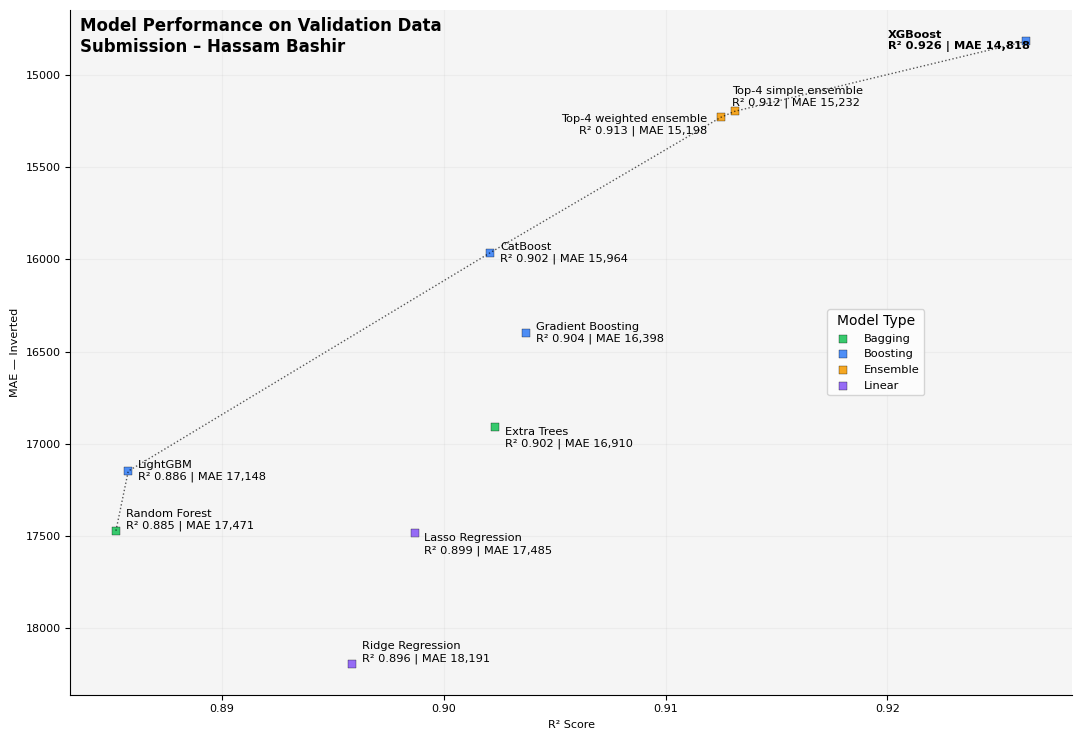

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = final_model_and_ensemble_comparison.copy()
plot_df = plot_df[plot_df["model"] != "Elastic Net"].copy()

model_group = {
    "XGBoost": "Boosting",
    "CatBoost": "Boosting",
    "Gradient Boosting": "Boosting",
    "LightGBM": "Boosting",
    "Random Forest": "Bagging",
    "Extra Trees": "Bagging",
    "Top-4 simple ensemble": "Ensemble",
    "Top-4 weighted ensemble": "Ensemble",
    "Ridge Regression": "Linear",
    "Lasso Regression": "Linear"
}

plot_df["group"] = plot_df["model"].map(model_group)

color_map = {
    "Boosting": "#3B82F6",
    "Bagging": "#22C55E",
    "Ensemble": "#F59E0B",
    "Linear": "#8B5CF6"
}

plt.rcParams["font.family"] = ["DejaVu Sans", "Liberation Sans", "sans-serif"]

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.set_facecolor("#F5F5F5")

for group, data in plot_df.groupby("group"):
    ax.scatter(
        data["R2"],
        data["MAE"],
        s=28,
        marker="s",
        color=color_map[group],
        label=group,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.25
    )

label_offsets = {
    "XGBoost": (-100, 0, "left"),
    "Top-4 weighted ensemble": (-20, -10, "right"),
    "Top-4 simple ensemble": (8, 15, "left"),
    "CatBoost": (7, 0, "left"),
    "Gradient Boosting": (7, 0, "left"),
    "LightGBM": (7, 0, "left"),
    "Extra Trees": (7, -8, "left"),
    "Random Forest": (7, 8, "left"),
    "Lasso Regression": (7, -8, "left"),
    "Ridge Regression": (7, 8, "left")
}

for _, row in plot_df.iterrows():
    x_offset, y_offset, align = label_offsets[row["model"]]

    label = f"{row['model']}\nR² {row['R2']:.3f} | MAE {row['MAE']:,.0f}"

    ax.annotate(
        label,
        xy=(row["R2"], row["MAE"]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=8.2,
        fontweight="bold" if row["model"] == "XGBoost" else "normal",
        ha=align,
        va="center"
    )

# Pareto frontier line
pareto_df = plot_df.sort_values("R2")

pareto_points = []
best_mae = float("inf")

for _, row in pareto_df.iterrows():
    if row["MAE"] < best_mae:
        pareto_points.append(row)
        best_mae = row["MAE"]

pareto_df = pd.DataFrame(pareto_points)

ax.plot(
    pareto_df["R2"],
    pareto_df["MAE"],
    linestyle="dotted",
    linewidth=1,
    color="black",
    alpha=0.65
)

ax.set_xlabel("R² Score", fontsize=8)
ax.set_ylabel("MAE — Inverted", fontsize=8)

ax.tick_params(axis='both', labelsize=8)
ax.text(
    0.01, 0.99,
    "Model Performance on Validation Data\nSubmission – Hassam Bashir",
    transform=ax.transAxes,
    fontsize=12,
    va='top',
    ha='left',
    fontweight="bold"
)

ax.invert_yaxis()

ax.grid(alpha=0.12)

ax.legend(
    title="Model Type",
    frameon=True,
    loc="center left",
    fontsize=8.2,
    bbox_to_anchor=(0.75, 0.5)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

In [44]:
try:
    from xgboost import XGBRegressor
except ImportError as error:
    raise ImportError(
        "XGBoost is not installed in this environment. "
        "Run this cell on Kaggle, or install xgboost locally before creating the submission."
    ) from error

try:
    train_submission = pd.read_csv("train.csv")
    test_submission = pd.read_csv("test.csv")
except FileNotFoundError:
    train_submission = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
    test_submission = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

# Keep test Id for the final Kaggle file, but do not use Id as a model feature.
test_ids = test_submission["Id"].copy()

X_full = train_submission.drop(["Id", "SalePrice"], axis=1)
y_full = train_submission["SalePrice"]
X_test = test_submission.drop("Id", axis=1)

# Apply the exact same feature engineering to full train and test.
X_full_fe = add_house_features(X_full)
X_test_fe = add_house_features(X_test)

numeric_features_submission = X_full_fe.select_dtypes(include=["int64", "float64"]).columns
categorical_features_submission = X_full_fe.select_dtypes(include=["object"]).columns

numeric_transformer_submission = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_submission = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_submission = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_submission, numeric_features_submission),
        ("cat", categorical_transformer_submission, categorical_features_submission)
    ]
)

final_xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor_submission),
    ("model", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

final_xgboost_model.fit(X_full_fe, y_full)

test_predictions = final_xgboost_model.predict(X_test_fe)
test_predictions = np.maximum(test_predictions, 0)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Created submission.csv")
print("Submission shape:", submission.shape)
submission.head()

Created submission.csv
Submission shape: (1459, 2)


,Id,SalePrice
0,1461,127175.273438
1,1462,163258.156250
2,1463,184705.640625
3,1464,192619.812500
4,1465,178690.859375


In [45]:
!kaggle competitions submit -c house-prices-advanced-regression-techniques -f /kaggle/working/submission.csv -m "XGBoost feature engineered submission"


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 60, in create_connection
    for res in socket.getaddrinfo(host, port, family, socket.SOCK_STREAM):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 978, in getaddrinfo
    for res in _socket.getaddrinfo(host, port, family, type, proto, flags):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
socket.gaierror: [Errno -3] Temporary failure in name resolution

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
             